Why do we need activation functions in the first place?

f(x) = 2 x + 3 and g(x) = 5 x - 1

 f(g(x)) = 2(5 x - 1) + 3 = 10 x + 1

logistic function, σ(z) =
1 / (1 + exp(–z)).

hyperbolic tangent function tanh(z) = 2σ(2z) – 1

Rectified Linear Unit function: ReLU(z) = max(0, z)

#Regression MLPs


First, MLPs can be used for regression tasks. If you want to predict a single value (e.g.,
the price of a house given many of its features), then you just need a single output
neuron: its output is the predicted value. For multivariate regression (i.e., to predict
multiple values at once), you need one output neuron per output dimension. For
example, to locate the center of an object on an image, you need to predict 2D coordi‐
nates, so you need two output neurons.

no activation function in output layer for regression task

output will always be positive, then you
can use the ReLU activation function, or the softplus activation function in the output
layer.

predictions will fall within a given
range of values, then you can use the logistic function or the hyperbolic tangent

The loss function to use during training is typically the mean squared error, but if you
have a lot of outliers in the training set, you may prefer to use the mean absolute
error

# Classification MLPs

MLPs can also be used for classification tasks. For a binary classification problem,
you just need a single output neuron using the logistic activation function: the output
will be a number between 0 and 1

, which you can interpret as the estimated probabil‐
ity of the positive class. Obviously, the estimated probability of the negative class is
equal to one minus that number.

MLPs can also easily handle multilabel binary classification tasks. For
example, you could have an email classification system that predicts whether each
incoming email is ham or spam, and simultaneously predicts whether it is an urgent
or non-urgent email.




If each instance can belong only to a single class, out of 3 or more possible classes
(e.g., classes 0 through 9 for digit image classification), then you need to have one
output neuron per class, and you should use the softmax activation function for the
whole output layer. The softmax function
will ensure that all the estimated probabilities are between 0 and 1 and that they add
up to one (which is required if the classes are exclusive). This is called multiclass clas‐
sification.


Cross Entropy like we did in previous class for customer churn prediction (A c lassification problem)

To Summarise activation function

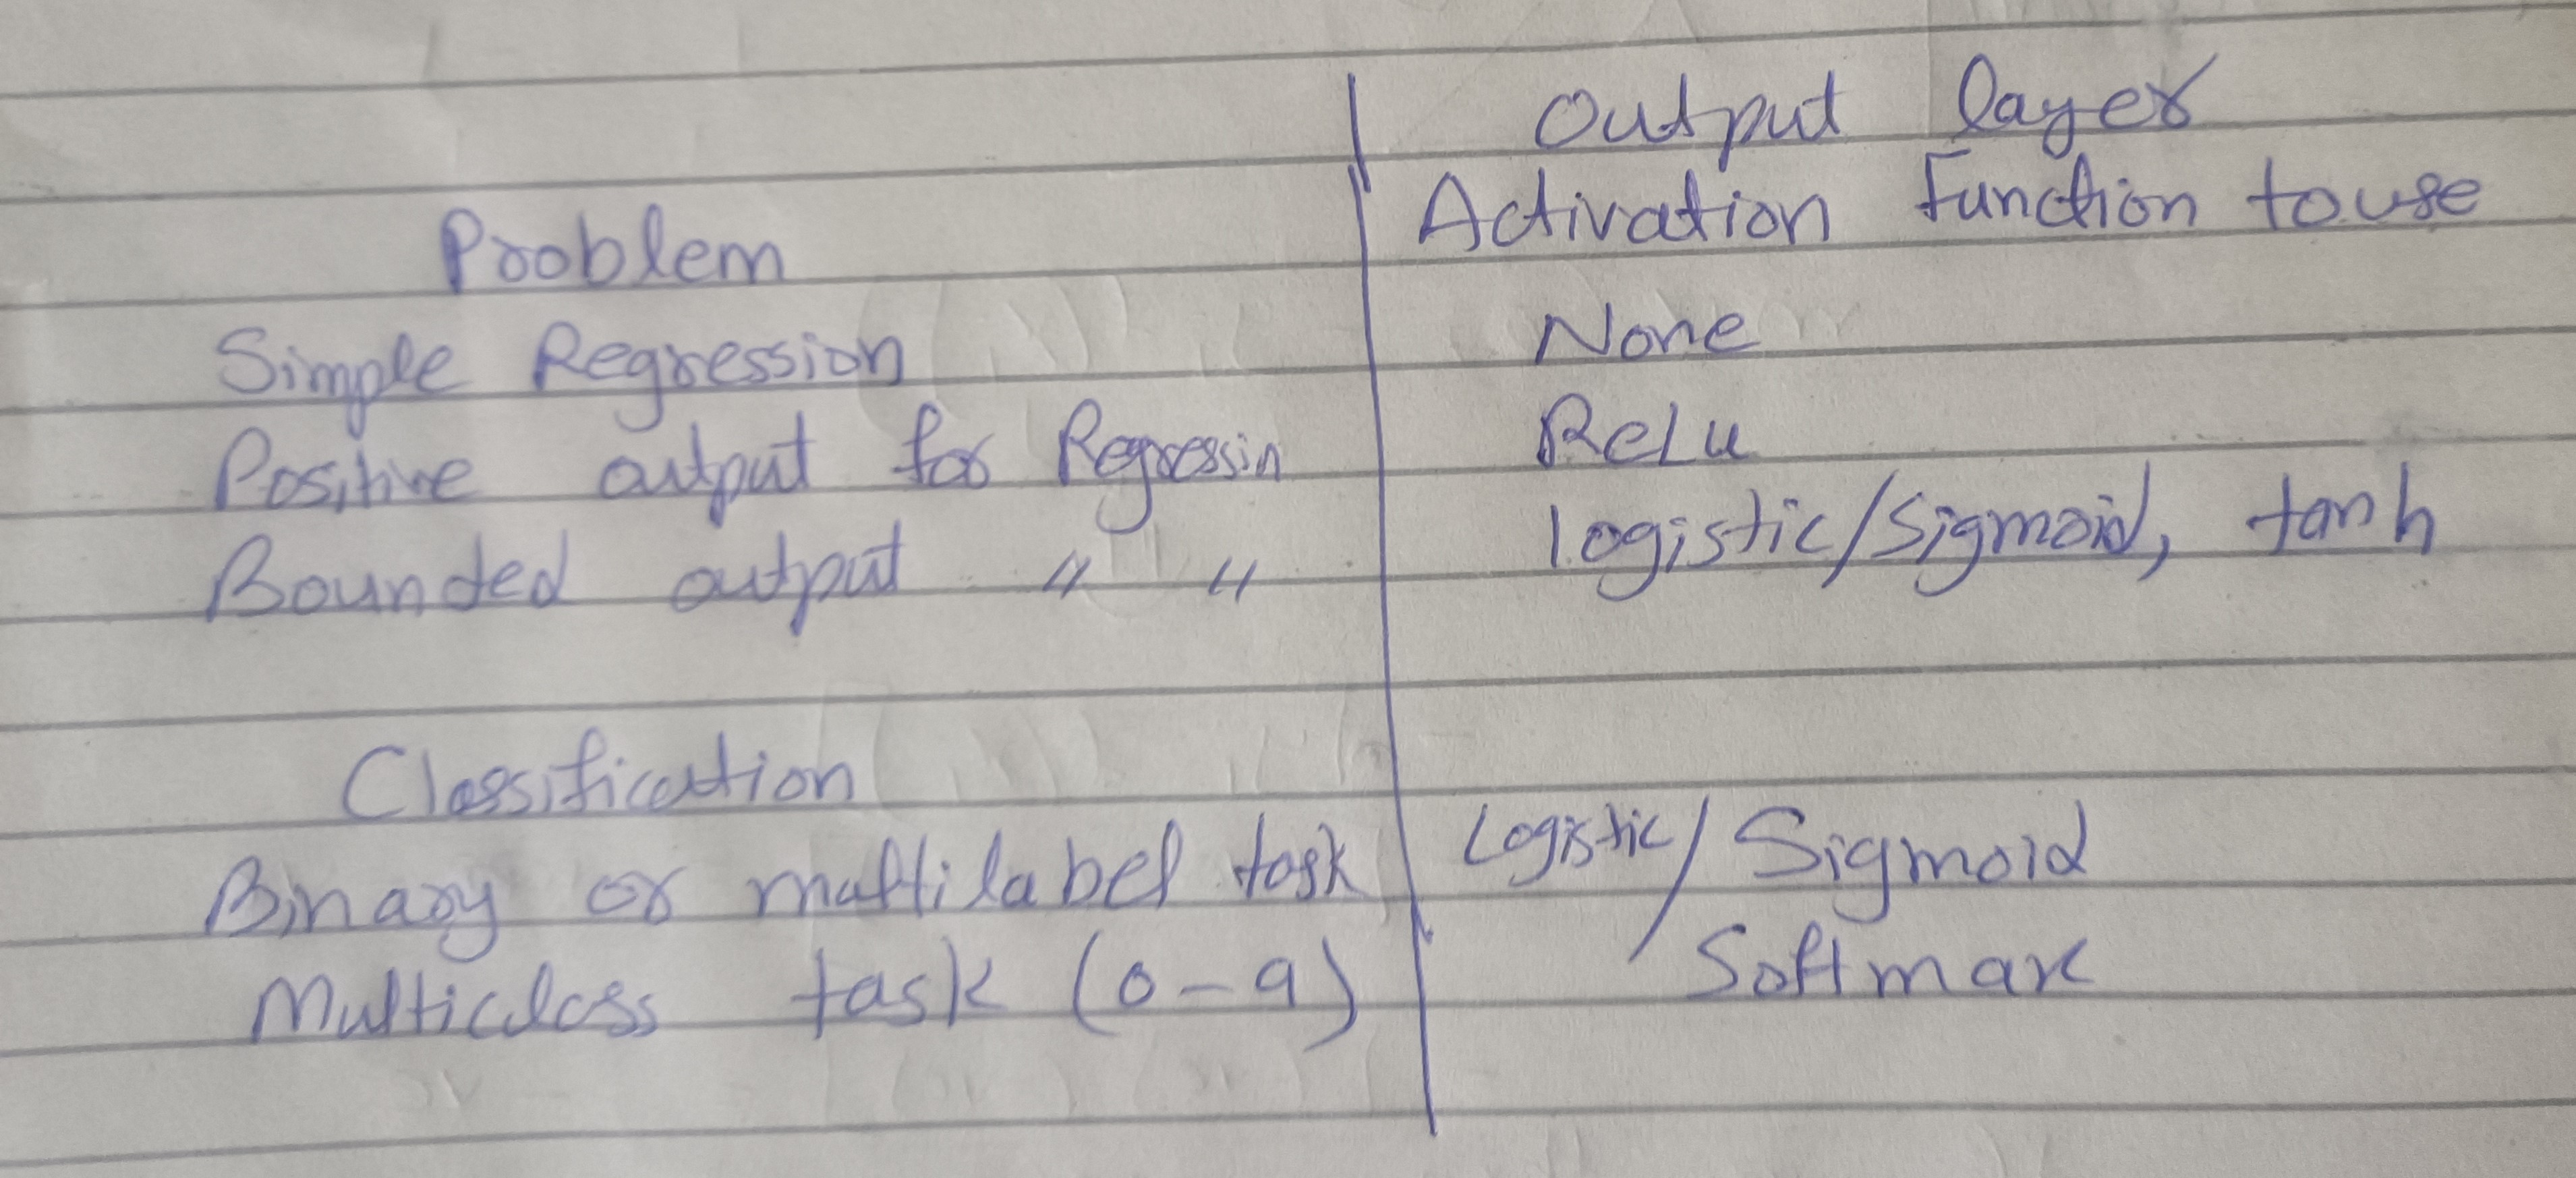

In [2]:
import tensorflow as tf
from tensorflow import keras


In [3]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
X_train_full.shape


(60000, 28, 28)

In [5]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]


In [6]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
 "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [7]:
class_names[y_train[1]]


'T-shirt/top'

In [8]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

the first hidden
layer has 784 × 300 connection weights, plus 300 bias terms, which adds up to
235,500 parameters

In [10]:
 old_weights, old_biases = model.layers[2].get_weights()


In [11]:
old_weights

array([[ 0.07506969, -0.06491147, -0.04139417, ..., -0.06415239,
         0.05549093, -0.06206802],
       [-0.09583897, -0.09499515, -0.03519011, ...,  0.0570899 ,
         0.00787929, -0.09500434],
       [ 0.00014606,  0.07297605,  0.01436802, ..., -0.09809866,
         0.07977008, -0.05154418],
       ...,
       [-0.0116354 , -0.03253272, -0.01219064, ..., -0.02581055,
         0.03518844, -0.07367544],
       [ 0.1067783 , -0.09523725,  0.08765296, ..., -0.11811347,
         0.10034964, -0.11170195],
       [ 0.04708704,  0.11806678, -0.09281053, ..., -0.0469507 ,
        -0.06617362, -0.07377128]], dtype=float32)

In [12]:
old_biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

In [13]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])


This requires some explanation. First, we use the "sparse_categorical_crossen
tropy" loss because we have sparse labels (i.e., for each instance there is just a target
class index, from 0 to 9 in this case), and the classes are exclusive. If instead we had
one target probability per class for each instance (such as one-hot vectors, e.g. [0.,
0., 0., 1., 0., 0., 0., 0., 0., 0.] to represent class 3), then we would need
to use the "categorical_crossentropy" loss instead. If we were doing binary classi‐
fication (with one or more binary labels), then we would use the "sigmoid" (i.e.,
logistic) activation function in the output layer instead of the "softmax" activation
function, and we would use the "binary_crossentropy" loss.

In [14]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6951 - loss: 0.9773 - val_accuracy: 0.8208 - val_loss: 0.5236
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8234 - loss: 0.5108 - val_accuracy: 0.8414 - val_loss: 0.4644
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8382 - loss: 0.4613 - val_accuracy: 0.8542 - val_loss: 0.4298
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8508 - loss: 0.4249 - val_accuracy: 0.8468 - val_loss: 0.4442
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8620 - loss: 0.3989 - val_accuracy: 0.8606 - val_loss: 0.3958
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8615 - loss: 0.3937 - val_accuracy: 0.8718 - val_loss: 0.3754
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8692 - loss: 0.3682 - val_accuracy: 0.8746 - val_loss: 0.3672
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8752 - loss: 0.3512 - 

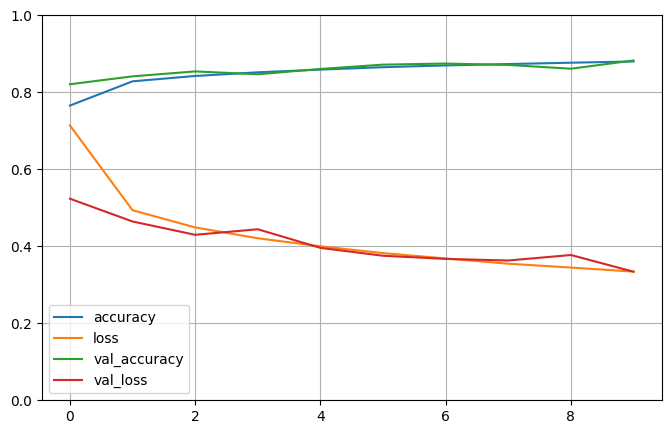

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()


In [17]:
model.evaluate(X_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8366 - loss: 66.1663


[70.4366226196289, 0.8287000060081482]

In [19]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [20]:
import numpy as np

y_pred = np.argmax(y_proba, axis=1)

In [21]:
y_pred


array([9, 2, 1])

In [22]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [23]:
y_new = y_test[:3]


In [24]:
y_new

array([9, 2, 1], dtype=uint8)

# Task

your task is to build a Regression MLP Using the Sequential API

In [25]:
from sklearn.datasets import fetch_california_housing


In [26]:
housing = fetch_california_housing()


In [27]:
new_weights, new_biases = model.layers[2].get_weights()


In [28]:
new_weights

array([[ 0.05452896, -0.06156303, -0.06518617, ..., -0.08644401,
         0.05108908, -0.05781274],
       [-0.1050557 , -0.11799223, -0.0081122 , ...,  0.06490297,
         0.01714782, -0.08872662],
       [ 0.02341318,  0.06245176,  0.03512522, ..., -0.08904149,
         0.0874466 , -0.05181321],
       ...,
       [ 0.03424918, -0.01069602, -0.01586189, ..., -0.03206572,
         0.0587501 , -0.07421693],
       [ 0.08531132, -0.10184357,  0.0585774 , ..., -0.12295612,
         0.10288208, -0.11197506],
       [ 0.05839717,  0.12275118, -0.11453877, ..., -0.05459755,
        -0.03431194, -0.07551979]], dtype=float32)

In [29]:
new_biases

array([ 3.73326018e-02, -4.76195812e-02, -4.15387526e-02, -5.45167073e-04,
        4.23275679e-03, -1.07975965e-02, -4.30612639e-02, -8.19886550e-02,
        6.04823139e-03,  1.64957754e-02,  1.29151300e-01, -5.66051640e-02,
       -1.34901153e-02,  1.04930587e-01,  9.90919322e-02,  6.54934272e-02,
       -7.71168768e-02, -2.65172664e-02,  5.98002132e-03,  1.96264312e-02,
        6.11770637e-02,  9.02092457e-02, -4.59598983e-03, -1.11946315e-01,
       -3.24779600e-02, -2.84062624e-02, -1.15542635e-02, -3.97857539e-02,
       -3.39742866e-03, -1.22659840e-01,  4.55524437e-02,  1.09369256e-01,
        2.33418178e-02,  1.59021094e-02, -1.79285556e-02,  6.90440685e-02,
       -3.41328159e-02, -1.11780100e-01,  1.59526662e-05,  9.91219133e-02,
        9.29578841e-02,  8.08908343e-02, -6.14053616e-03,  3.17080244e-02,
       -6.92365244e-02,  2.58047115e-02,  1.37128150e-02,  8.09239876e-03,
        4.58445176e-02, -8.40038341e-03,  1.10383771e-01, -4.13800729e-03,
       -6.27210066e-02,  

Did you remember how we update them baises and weights??

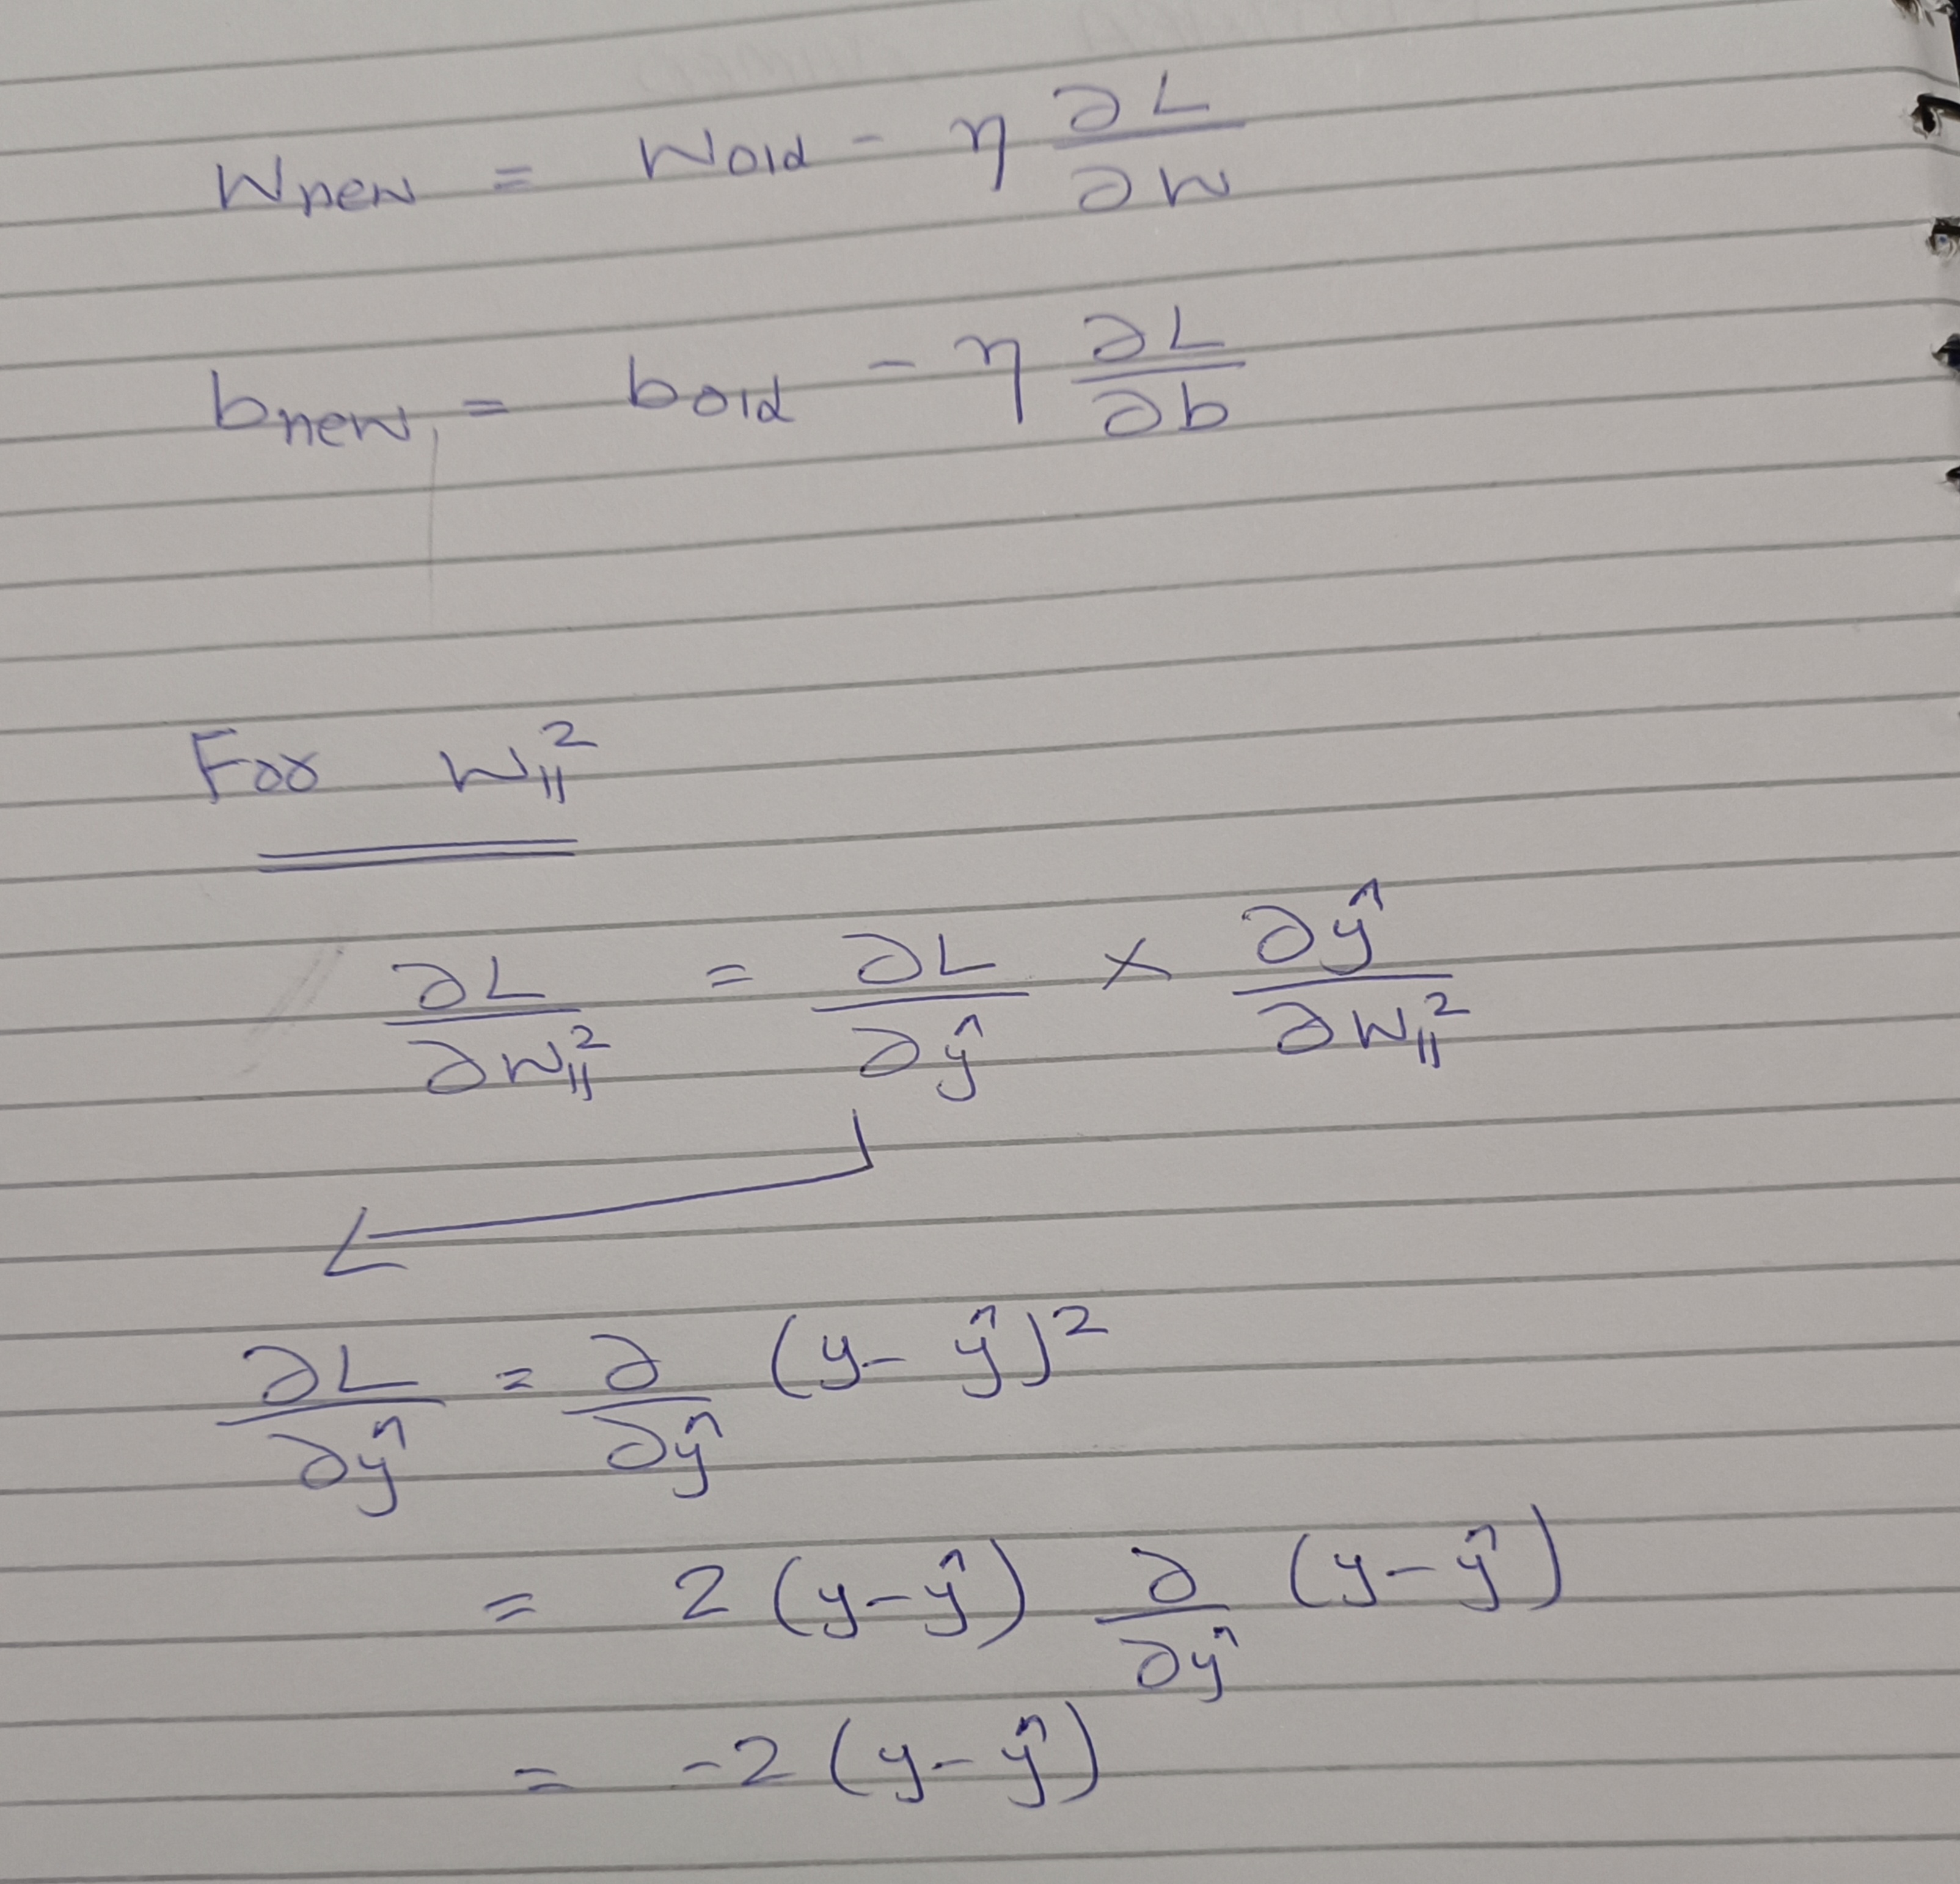

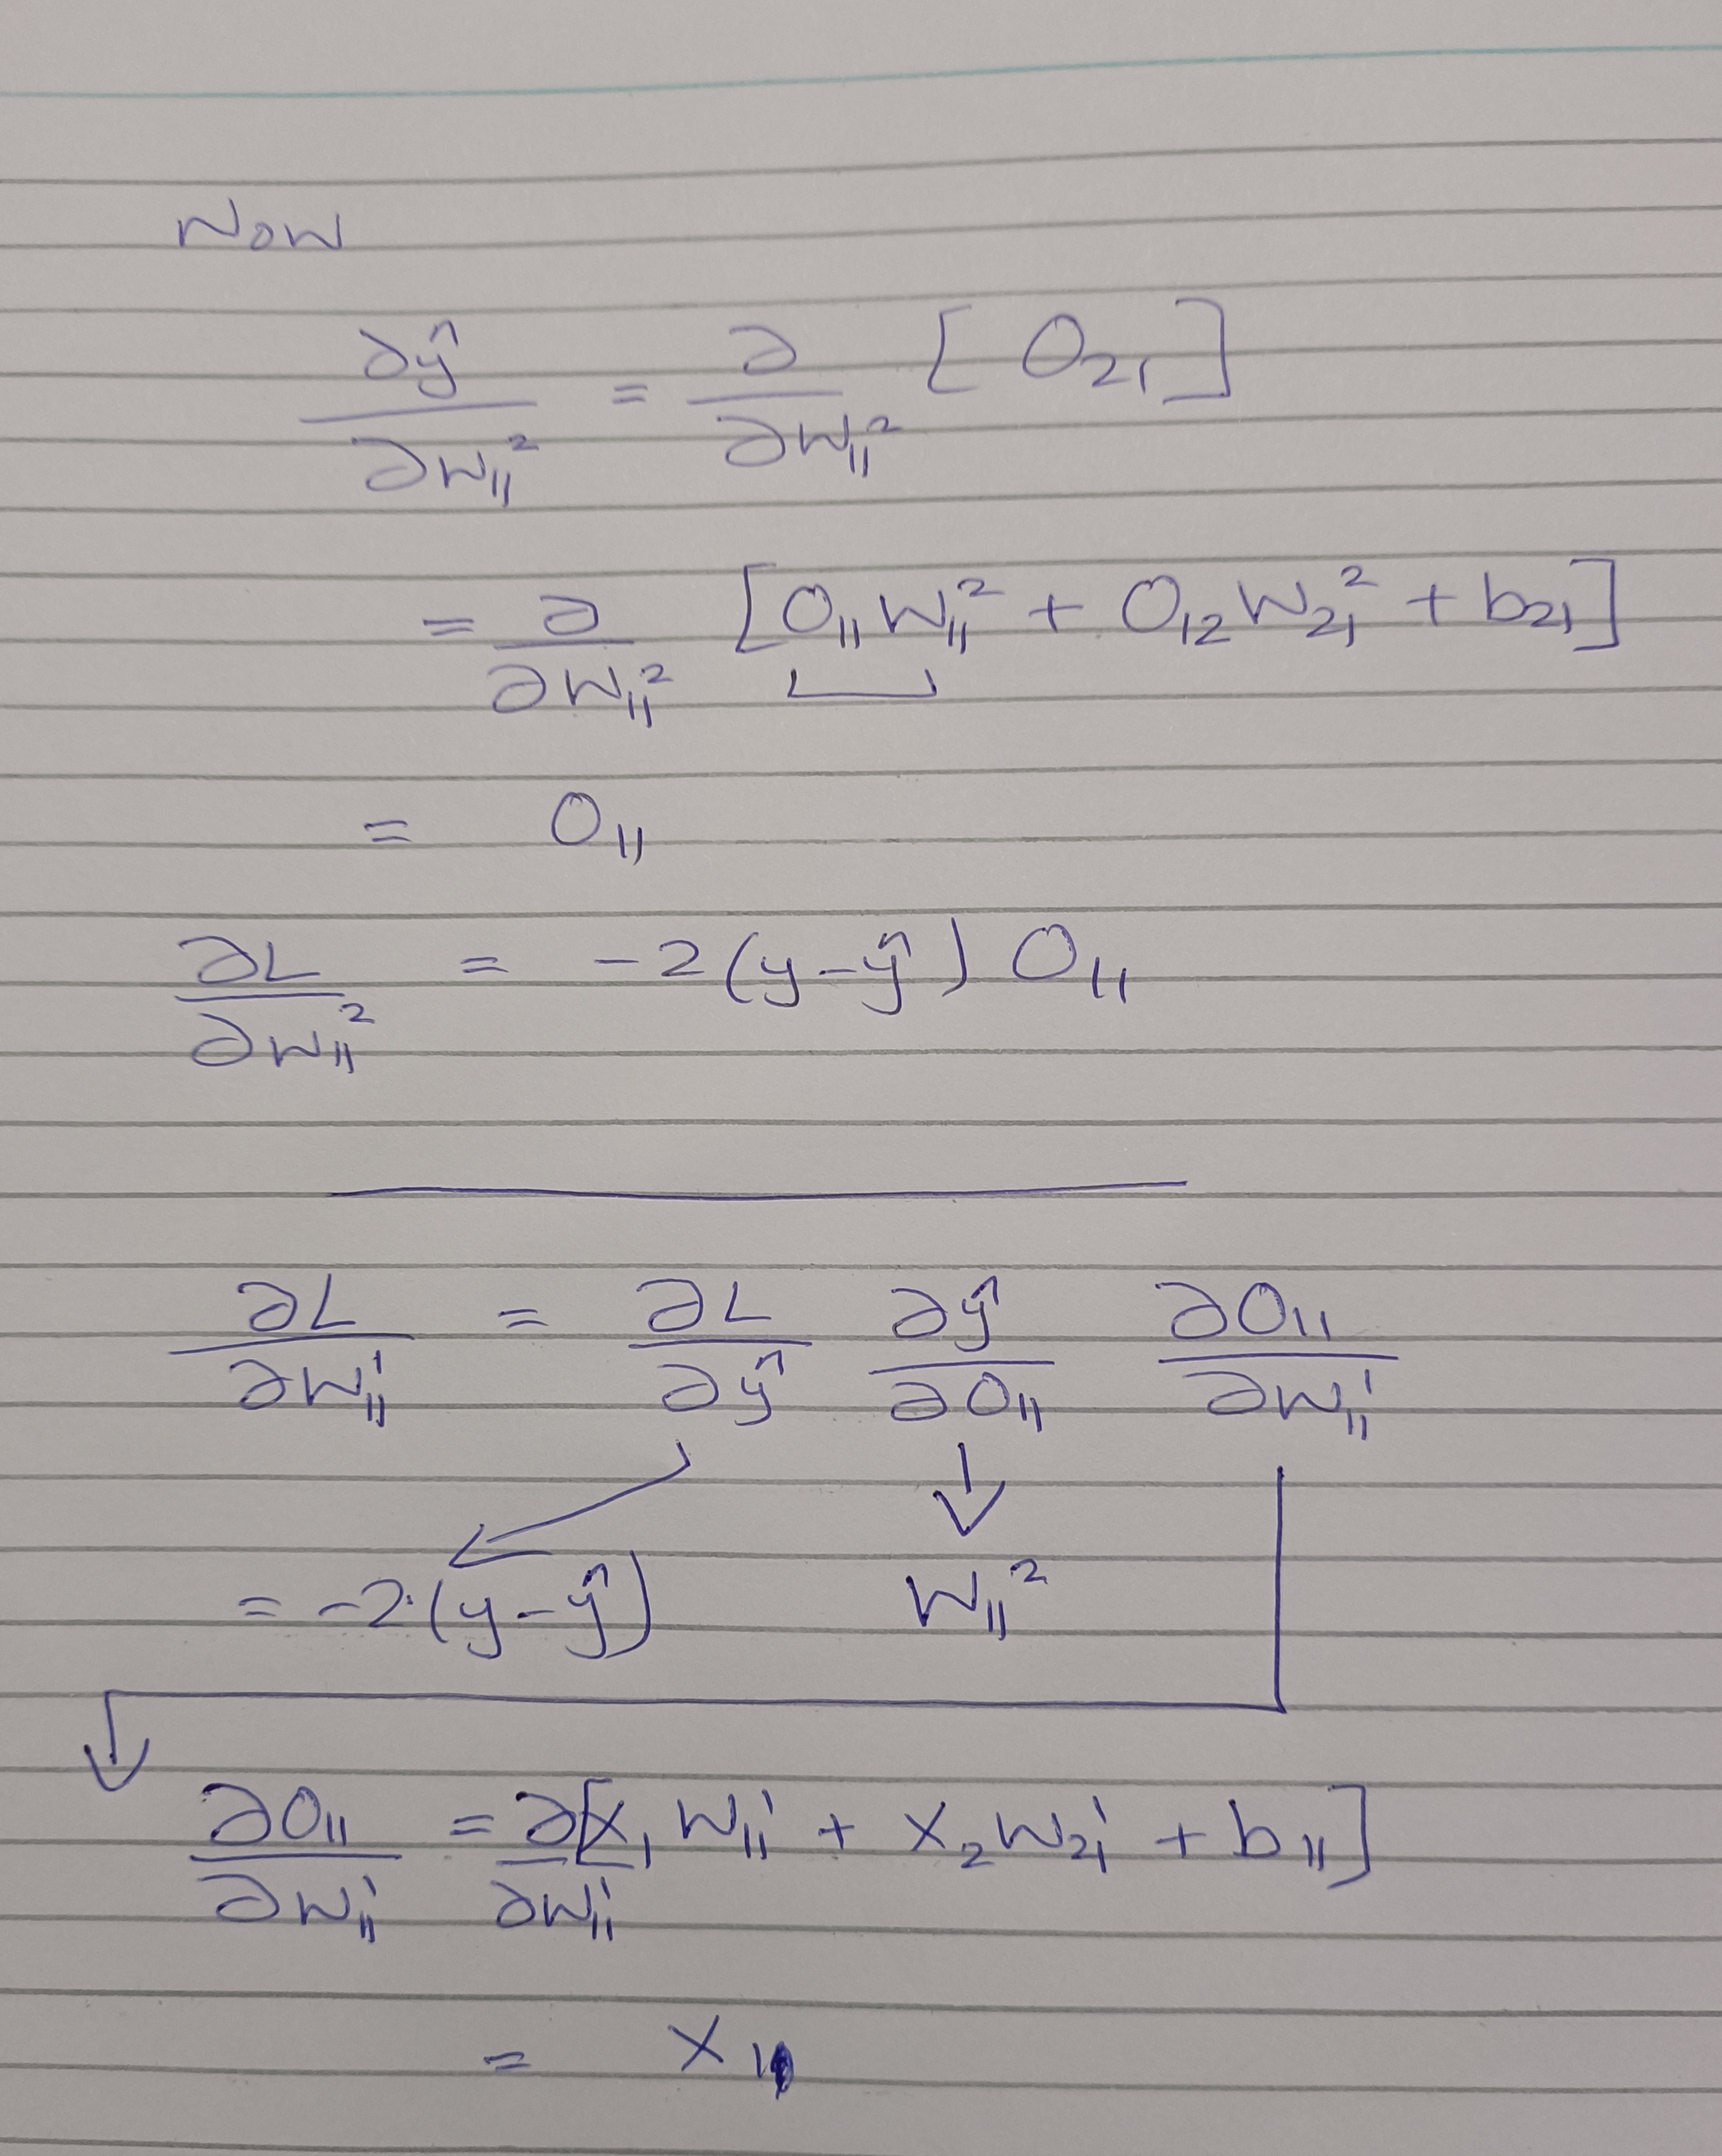